## Sales Data Analysis: Uncovering Trends and Insights from a Real-World Sales Dataset

In today’s competitive market, data-driven decision-making is crucial for businesses to optimize their sales strategies. Sales data contains valuable insights that can help organizations understand customer behavior, identify seasonal trends, and improve overall performance. By analyzing a real-world sales dataset, businesses can make informed decisions to boost revenue and enhance customer satisfaction.

## Objective

Your analysis in this mini project will focus on cleaning, exploring, and visualizing a sales dataset to extract meaningful insights using python and data visualization libraries.

## About the Dataset

The **[dataset](https://drive.google.com/file/d/1V6HTxMsNQswvL_K39UWB7dh8Un8f4oz7/view?usp=sharing)** used in this analysis is a real-world sales dataset containing transaction records from a retail business. It includes the following key features:

- `OrderID`: The id or the order that was placed.
- `Date`: The date the order was placed.
- `CustomerID`: The customer ID that represents the customer who made the purchase.
- `Product`: The class of product that was purchased.
- `Quantity`: The quantity of the product that was purchased.
- `Price`: Unit price of the product in dollars.
- `Total`: The total cost of the purchase in dollars.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
retail_df = pd.read_csv(r"Dataset.csv")
retail_df

,OrderID,Date,CustomerID,Product,Quantity,Price,Total
0,1,2024-04-12,C002,Phone,1,600,642.09
1,2,2024-12-14,C003,Laptop,2,1000,2098.39
2,3,2024-09-27,C017,Monitor,1,200,196.34
3,4,2024-04-16,C005,Phone,3,600,1955.86
4,5,2024-03-12,C017,Laptop,1,1000,1098.19
...,...,...,...,...,...,...,...
195,196,2024-04-22,C019,Monitor,1,200,181.37
196,197,2024-11-13,C017,Laptop,1,1000,1066.13
197,198,2024-02-21,C019,Tablet,1,400,387.62
198,199,2024-09-24,C005,Phone,2,600,1265.72


In [3]:
retail_df.duplicated().sum()

0

In [4]:
retail_df.isna().sum()

OrderID       0
Date          0
CustomerID    0
Product       0
Quantity      0
Price         0
Total         6
dtype: int64

In [5]:
retail_df['Total'].fillna(retail_df['Total'].mean(), inplace=True)

In [6]:
retail_df.isna().sum()

OrderID       0
Date          0
CustomerID    0
Product       0
Quantity      0
Price         0
Total         0
dtype: int64

In [7]:
retail_df[retail_df['Product'] == 'None']

,OrderID,Date,CustomerID,Product,Quantity,Price,Total
6,7,2024-01-21,C017,None,1,1000,975.850000
26,27,2024-09-09,C016,None,1,1000,1007.960000
28,29,2024-12-10,C009,None,2,600,1218.600000
35,36,2024-06-23,C003,None,1,600,591.780000
57,58,2024-09-20,C001,None,1,600,612.470000
62,63,2024-12-25,C009,None,2,1000,2108.750000
70,71,2024-02-13,C001,None,1,100,96.850000
163,164,2024-10-10,C014,None,3,1000,3031.030000
188,189,2024-06-20,C003,None,1,600,617.150000
189,190,2024-05-31,C008,None,1,1000,937.638711


In [8]:
ppm = retail_df[retail_df['Product']!= 'None'].set_index('Price')['Product'].to_dict()
retail_df.loc[retail_df[ 'Product'] == 'None', 'Product'] = retail_df.loc[retail_df[ 'Product'] == 'None', 'Price'].map(ppm)

In [9]:
retail_df[retail_df['Product'] == 'None']

,OrderID,Date,CustomerID,Product,Quantity,Price,Total


In [10]:
retail_df.describe(include="all")

,OrderID,Date,CustomerID,Product,Quantity,Price,Total
count,200.000000,200,200,200,200.00000,200.000000,200.000000
unique,NaN,152,20,5,NaN,NaN,NaN
top,NaN,2024-08-18,C003,Laptop,NaN,NaN,NaN
freq,NaN,4,17,81,NaN,NaN,NaN
mean,100.500000,NaN,NaN,NaN,1.36500,676.000000,937.638711
std,57.879185,NaN,NaN,NaN,0.61943,300.291316,644.229346
min,1.000000,NaN,NaN,NaN,1.00000,100.000000,93.310000
25%,50.750000,NaN,NaN,NaN,1.00000,400.000000,565.945000
50%,100.500000,NaN,NaN,NaN,1.00000,600.000000,886.410000
75%,150.250000,NaN,NaN,NaN,2.00000,1000.000000,1062.367500


In [11]:
retail_df['Date'] = pd.to_datetime(retail_df['Date'])

In [12]:
retail_df

,OrderID,Date,CustomerID,Product,Quantity,Price,Total
0,1,2024-04-12,C002,Phone,1,600,642.09
1,2,2024-12-14,C003,Laptop,2,1000,2098.39
2,3,2024-09-27,C017,Monitor,1,200,196.34
3,4,2024-04-16,C005,Phone,3,600,1955.86
4,5,2024-03-12,C017,Laptop,1,1000,1098.19
...,...,...,...,...,...,...,...
195,196,2024-04-22,C019,Monitor,1,200,181.37
196,197,2024-11-13,C017,Laptop,1,1000,1066.13
197,198,2024-02-21,C019,Tablet,1,400,387.62
198,199,2024-09-24,C005,Phone,2,600,1265.72


<Axes: >

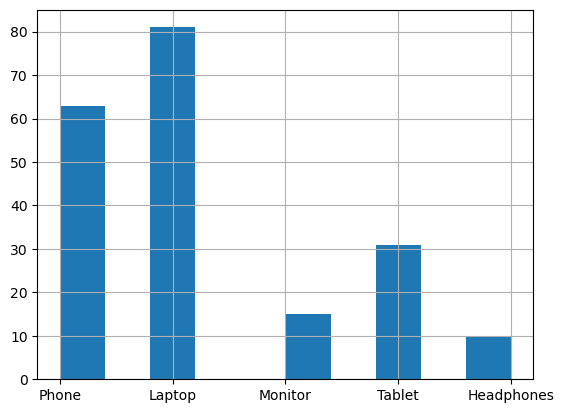

In [13]:
# Which Produvt Has The Most Sales 
retail_df['Product'].hist()

<Axes: xlabel='Date', ylabel='count'>

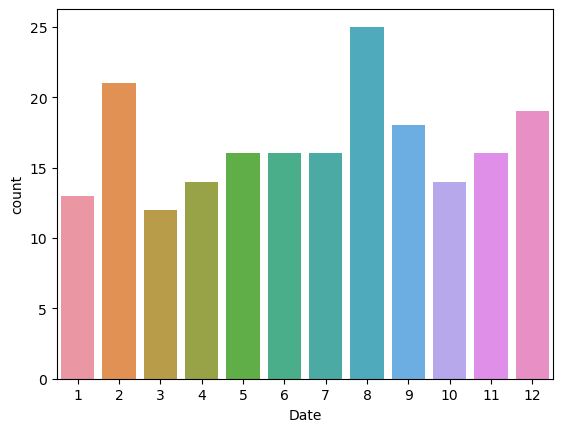

In [14]:
# Which month were most sales recorded
sns.countplot(data= retail_df,x=retail_df['Date'].dt.month)

<Axes: xlabel='Product', ylabel='count'>

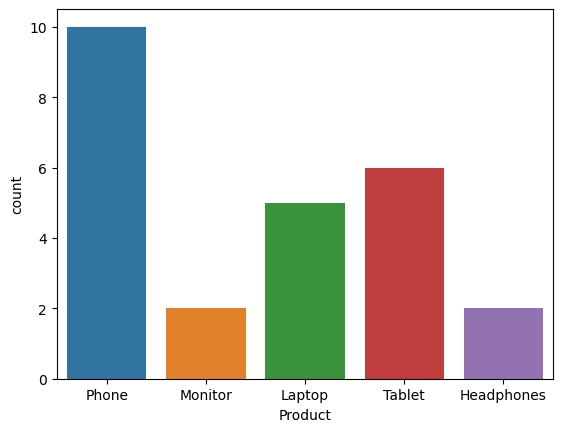

In [15]:
#What product id mostly sold in month 8
hms = retail_df[retail_df['Date'].dt.month == 8]
sns.countplot(data= hms,x=hms['Product'])

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 [Text(0, 0, 'C002'),
  Text(1, 0, 'C003'),
  Text(2, 0, 'C017'),
  Text(3, 0, 'C005'),
  Text(4, 0, 'C001'),
  Text(5, 0, 'C019'),
  Text(6, 0, 'C012'),
  Text(7, 0, 'C006'),
  Text(8, 0, 'C004'),
  Text(9, 0, 'C011'),
  Text(10, 0, 'C020'),
  Text(11, 0, 'C016'),
  Text(12, 0, 'C009'),
  Text(13, 0, 'C007'),
  Text(14, 0, 'C008'),
  Text(15, 0, 'C018'),
  Text(16, 0, 'C010'),
  Text(17, 0, 'C014'),
  Text(18, 0, 'C013'),
  Text(19, 0, 'C015')])

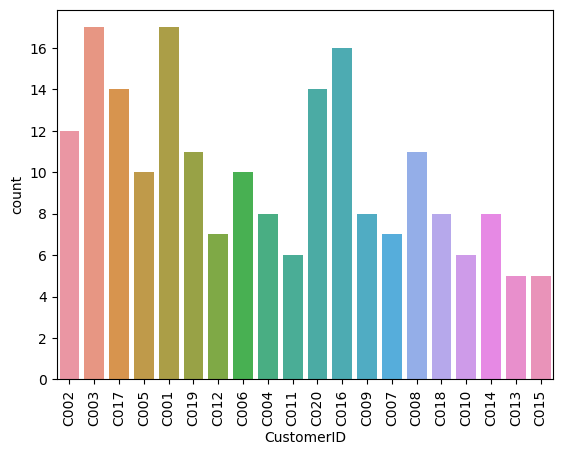

In [16]:
# Are there any return customers
sns.countplot(data= retail_df,x=retail_df['CustomerID'])
plt.xticks(rotation= 90)

<Axes: xlabel='Product', ylabel='Price'>

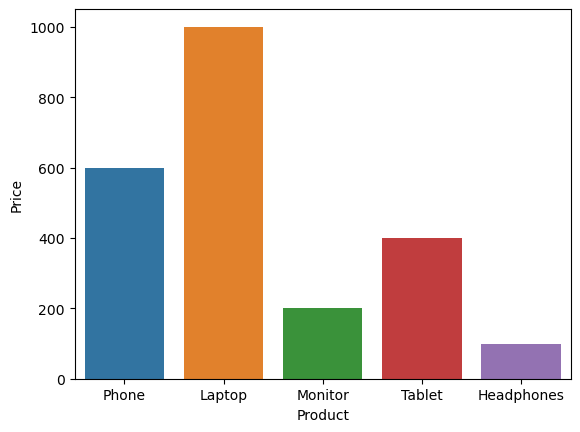

In [17]:
# Which Product is the most expensive
sns.barplot(x= retail_df['Product'] ,y= retail_df['Price'])

<Axes: xlabel='Date', ylabel='Total'>

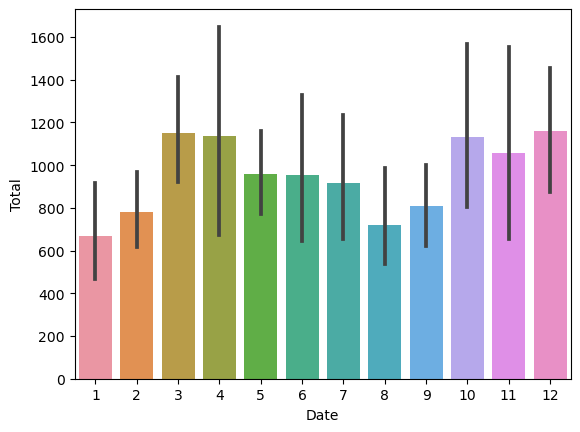

In [18]:
# Total amount made per month
sns.barplot(data= retail_df,x=retail_df['Date'].dt.month, y= retail_df['Total'])

In [26]:
# Correlation between price and customer return and product
retail_df
pd.crosstab(retail_df['CustomerID'], [retail_df['Product'],retail_df['Price']])

Product,Headphones,Laptop,Monitor,Phone,Tablet
Price,100,1000,200,600,400
CustomerID,,,,,
C001,2,5,2,4,4
C002,1,5,1,4,1
C003,0,4,0,7,6
C004,0,5,0,1,2
C005,1,4,0,5,0
C006,0,8,0,1,1
C007,1,1,0,4,1
C008,1,3,1,5,1


In [20]:
# Ave total made in each quater
retail_df['quater'] = retail_df['Date'].dt.to_period('Q')
total_sales = retail_df.groupby('quater')['Total'].sum()

<Axes: xlabel='quater'>

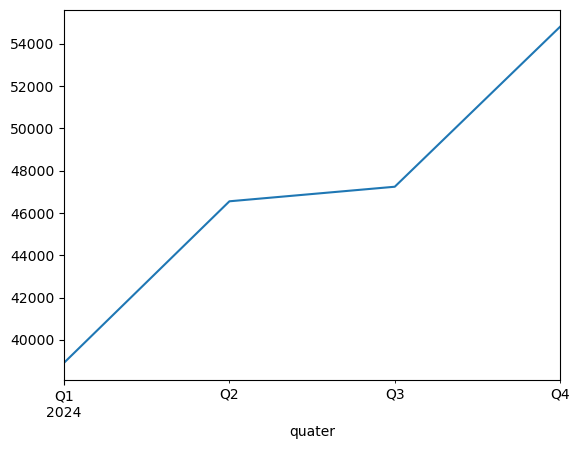

In [21]:
total_sales.plot()